In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection  import train_test_split
from sklearn.linear_model import LogisticRegression,LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,mean_squared_error, r2_score
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.naive_bayes import GaussianNB


data=pd.read_csv('/content/oral_cancer_prediction_dataset (1).csv')
df=pd.DataFrame(data)
df.head()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   ID                                        84922 non-null  int64  
 1   Country                                   84922 non-null  object 
 2   Age                                       84922 non-null  int64  
 3   Gender                                    84922 non-null  object 
 4   Tobacco Use                               84922 non-null  object 
 5   Alcohol Consumption                       84922 non-null  object 
 6   HPV Infection                             84922 non-null  object 
 7   Betel Quid Use                            84922 non-null  object 
 8   Chronic Sun Exposure                      84922 non-null  object 
 9   Poor Oral Hygiene                         84922 non-null  object 
 10  Diet (Fruits & Vegetables Intake) 

In [ ]:
df.isnull().sum()

,0
ID,0
Country,0
Age,0
Gender,0
Tobacco Use,0
Alcohol Consumption,0
HPV Infection,0
Betel Quid Use,0
Chronic Sun Exposure,0
Poor Oral Hygiene,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop(['ID'],axis=1,inplace=True)

In [ ]:
df.shape

(84922, 24)

In [ ]:
df.columns

Index(['Country', 'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption',
       'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure',
       'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
       'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
       'Unexplained Bleeding', 'Difficulty Swallowing',
       'White or Red Patches in Mouth', 'Tumor Size (cm)', 'Cancer Stage',
       'Treatment Type', 'Survival Rate (5-Year, %)',
       'Cost of Treatment (USD)', 'Economic Burden (Lost Workdays per Year)',
       'Early Diagnosis', 'Oral Cancer (Diagnosis)'],
      dtype='object')

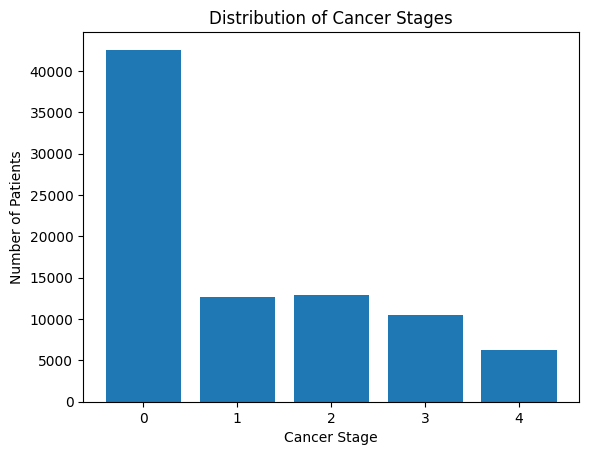

In [ ]:
stage_counts = df['Cancer Stage'].value_counts().sort_index()

plt.figure()
plt.bar(stage_counts.index, stage_counts.values)
plt.xlabel("Cancer Stage")
plt.ylabel("Number of Patients")
plt.title("Distribution of Cancer Stages")
plt.show()

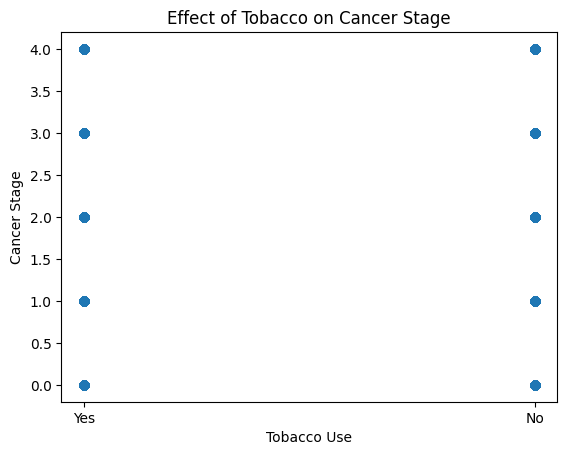

In [ ]:
plt.figure()
plt.scatter(df['Tobacco Use'], df['Cancer Stage'])
plt.xlabel("Tobacco Use")
plt.ylabel("Cancer Stage")
plt.title("Effect of Tobacco on Cancer Stage")
plt.show()

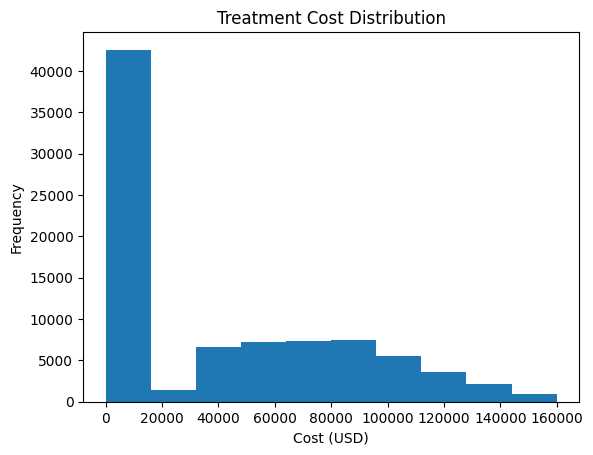

In [ ]:
plt.figure()
plt.hist(df['Cost of Treatment (USD)'])
plt.xlabel("Cost (USD)")
plt.ylabel("Frequency")
plt.title("Treatment Cost Distribution")
plt.show()

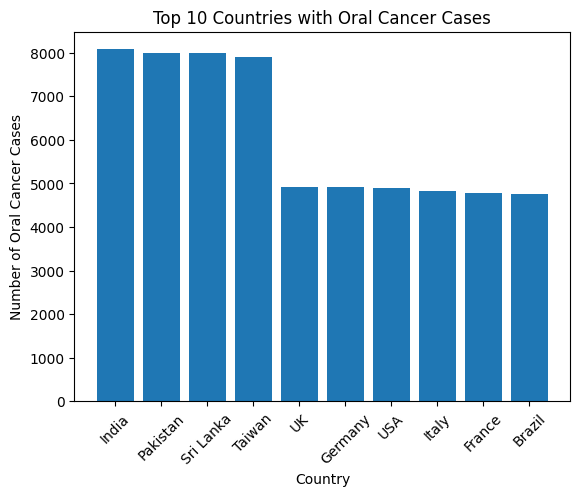

In [ ]:
top10_country = df['Country'].value_counts().head(10)

plt.figure()
plt.bar(top10_country.index, top10_country.values)
plt.xlabel("Country")
plt.ylabel("Number of Oral Cancer Cases")
plt.title("Top 10 Countries with Oral Cancer Cases")
plt.xticks(rotation=45)
plt.show()

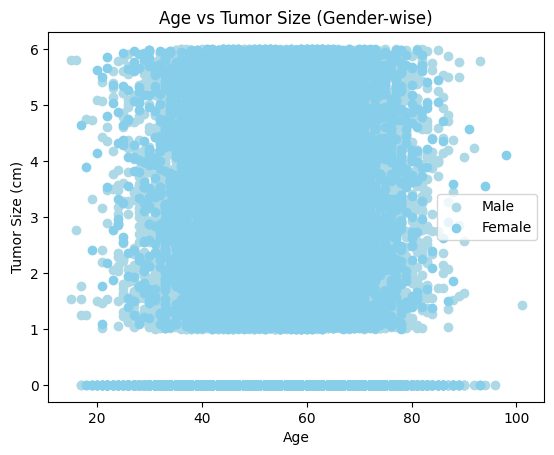

In [ ]:
male = df[df['Gender'] == 'Male']
female = df[df['Gender'] == 'Female']

plt.figure()
plt.scatter(male['Age'], male['Tumor Size (cm)'], color='lightblue', label='Male')
plt.scatter(female['Age'], female['Tumor Size (cm)'], color='skyblue', label='Female')

plt.xlabel("Age")
plt.ylabel("Tumor Size (cm)")
plt.title("Age vs Tumor Size (Gender-wise)")
plt.legend()
plt.show()

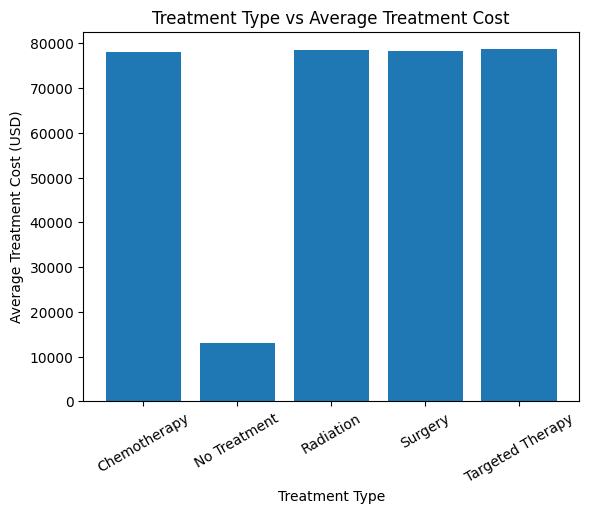

In [ ]:
treatment_cost = df.groupby('Treatment Type')['Cost of Treatment (USD)'].mean()

plt.figure()
plt.bar(treatment_cost.index, treatment_cost.values)
plt.xlabel("Treatment Type")
plt.ylabel("Average Treatment Cost (USD)")
plt.title("Treatment Type vs Average Treatment Cost")
plt.xticks(rotation=30)
plt.show()

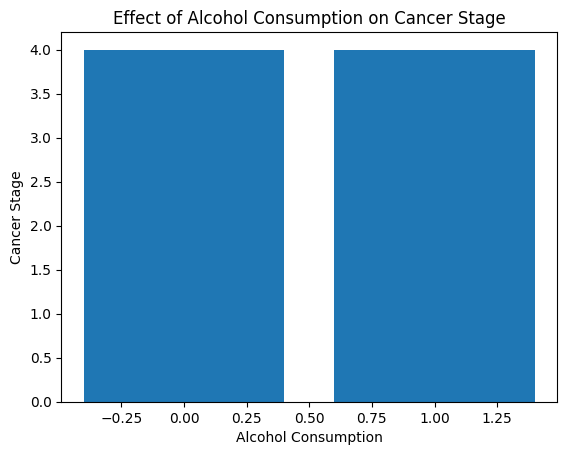

In [ ]:
plt.figure()
plt.bar(df['Alcohol Consumption'],df['Cancer Stage' ])
plt.xlabel("Alcohol Consumption")
plt.ylabel("Cancer Stage")
plt.title("Effect of Alcohol Consumption on Cancer Stage")
plt.show()

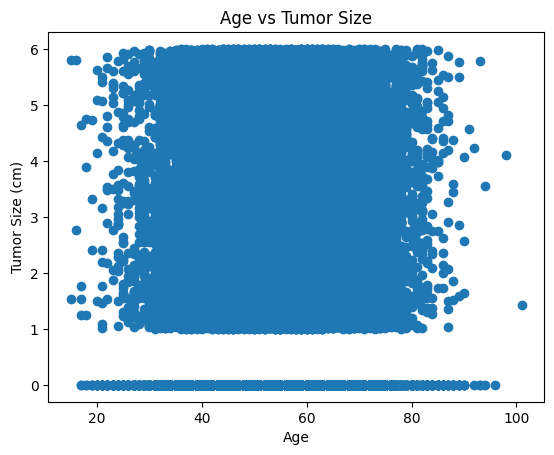

In [ ]:
plt.figure()
plt.scatter(df['Age'], df['Tumor Size (cm)'])
plt.xlabel("Age")
plt.ylabel("Tumor Size (cm)")
plt.title("Age vs Tumor Size")
plt.show()

In [ ]:
for col in df.columns:
    print(f"\n{col} unique values:")
    print(df[col].unique())


Country unique values:
['Italy' 'Japan' 'UK' 'Sri Lanka' 'South Africa' 'Taiwan' 'USA' 'Germany'
 'France' 'Australia' 'Brazil' 'Pakistan' 'Kenya' 'Russia' 'Nigeria'
 'Egypt' 'India']

Age unique values:
[ 36  64  37  55  68  70  41  53  62  50  65  34  56  59  43  63  44  71
  51  47  58  57  54  67  31  66  48  61  46  49  60  74  42  73  69  35
  52  39  40  45  28  38  33  75  78  72  76  29  80  32  26  77  30  79
  82  89  23  22  81  18  24  83  25  86  21  87  19  27  17  85  84  20
  88  15  93  92  94  90  96  16  91 101  98]

Gender unique values:
['Female' 'Male']

Tobacco Use unique values:
['Yes' 'No']

Alcohol Consumption unique values:
['Yes' 'No']

HPV Infection unique values:
['Yes' 'No']

Betel Quid Use unique values:
['No' 'Yes']

Chronic Sun Exposure unique values:
['No' 'Yes']

Poor Oral Hygiene unique values:
['Yes' 'No']

Diet (Fruits & Vegetables Intake) unique values:
['Low' 'High' 'Moderate']

Family History of Cancer unique values:
['No' 'Yes']

Compromised

In [ ]:
df.drop(['Country'],axis=1,inplace=True)

In [ ]:
le = LabelEncoder()
categorical_cols = ['Gender','Tobacco Use','Alcohol Consumption','HPV Infection',
                    'Betel Quid Use','Chronic Sun Exposure','Poor Oral Hygiene','Family History of Cancer',
                    'Compromised Immune System','Oral Lesions','Unexplained Bleeding','Difficulty Swallowing',
                    'White or Red Patches in Mouth','Early Diagnosis','Oral Cancer (Diagnosis)']
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),Family History of Cancer,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,36,0,1,1,1,0,0,1,Low,0,...,0,0,0.000000,0,No Treatment,100.000000,0.00,0,0,0
1,64,1,1,1,1,0,1,1,High,0,...,0,0,1.782186,1,No Treatment,83.340103,77772.50,177,0,1
2,37,0,0,1,0,0,1,1,Moderate,0,...,0,1,3.523895,2,Surgery,63.222871,101164.50,130,1,1
3,55,1,1,1,0,1,0,1,Moderate,0,...,0,0,0.000000,0,No Treatment,100.000000,0.00,0,1,0
4,68,1,0,0,0,0,0,1,High,0,...,0,0,2.834789,3,No Treatment,44.293199,45354.75,52,0,1


In [ ]:
multi_columns=['Diet (Fruits & Vegetables Intake)', 'Treatment Type']
df=pd.get_dummies(df,columns=multi_columns,drop_first=True)
df.head()

,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Family History of Cancer,Compromised Immune System,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),Diet (Fruits & Vegetables Intake)_Low,Diet (Fruits & Vegetables Intake)_Moderate,Treatment Type_No Treatment,Treatment Type_Radiation,Treatment Type_Surgery,Treatment Type_Targeted Therapy
0,36,0,1,1,1,0,0,1,0,0,...,0.00,0,0,0,True,False,True,False,False,False
1,64,1,1,1,1,0,1,1,0,0,...,77772.50,177,0,1,False,False,True,False,False,False
2,37,0,0,1,0,0,1,1,0,0,...,101164.50,130,1,1,False,True,False,False,True,False
3,55,1,1,1,0,1,0,1,0,0,...,0.00,0,1,0,False,True,True,False,False,False
4,68,1,0,0,0,0,0,1,0,0,...,45354.75,52,0,1,False,False,True,False,False,False


In [ ]:
df.shape

(84922, 27)

In [ ]:
df=df.replace({True:1,False:0,'True':1,'False':0})
df.head()

/tmp/ipython-input-1488194897.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace({True:1,False:0,'True':1,'False':0})


,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Family History of Cancer,Compromised Immune System,...,Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis),Diet (Fruits & Vegetables Intake)_Low,Diet (Fruits & Vegetables Intake)_Moderate,Treatment Type_No Treatment,Treatment Type_Radiation,Treatment Type_Surgery,Treatment Type_Targeted Therapy
0,36,0,1,1,1,0,0,1,0,0,...,0.00,0,0,0,1,0,1,0,0,0
1,64,1,1,1,1,0,1,1,0,0,...,77772.50,177,0,1,0,0,1,0,0,0
2,37,0,0,1,0,0,1,1,0,0,...,101164.50,130,1,1,0,1,0,0,1,0
3,55,1,1,1,0,1,0,1,0,0,...,0.00,0,1,0,0,1,1,0,0,0
4,68,1,0,0,0,0,0,1,0,0,...,45354.75,52,0,1,0,0,1,0,0,0


In [ ]:
X=df.drop('Oral Cancer (Diagnosis)',axis=1)
y=df['Oral Cancer (Diagnosis)']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)


print(y_pred)
print(f'accuracy_score:{accuracy_score(y_test,y_pred):.2f}')
print(confusion_matrix(y_test,y_pred))

[0 1 1 ... 1 1 0]
accuracy_score:1.00
[[8560    0]
 [   0 8425]]


In [ ]:
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print(y_pred)
print(f"Linear Regression R2 Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")

[0.03520958 0.99047691 1.03610542 ... 0.70531446 0.77213476 0.03270056]
Linear Regression R2 Score: 0.93
Mean Squared Error: 0.02


In [ ]:
model=DecisionTreeClassifier(max_depth=3)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print(y_pred)
print(f'accuracy_score:{accuracy_score(y_test,y_pred):.2f}')

[0 1 1 ... 1 1 0]
accuracy_score:1.00


In [ ]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print(y_pred)
print(f'accuracy_score:{accuracy_score(y_test,y_pred):.2f}')

[0 1 1 ... 1 1 0]
accuracy_score:1.00


In [ ]:
from sklearn.cluster import KMeans
model=KMeans(n_clusters=2,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print(y_pred)
print(f'accuracy_score:{accuracy_score(y_test,y_pred):.2f}')

[0 1 1 ... 1 1 0]
accuracy_score:0.99


In [ ]:
from sklearn.svm import SVC
import pandas as pd

X=df.drop('Oral Cancer (Diagnosis)',axis=1)
y=df['Oral Cancer (Diagnosis)']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=SVC(kernel='linear')


model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print(y_pred)
print(f'accuracy_score:{accuracy_score(y_test,y_pred):.2f}')

[0 1 1 ... 1 1 0]
accuracy_score:1.00


In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,mean_squared_error, r2_score

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
y_pred = np.where(y_pred > 0.5, 1, 0)

print(y_pred)

print(f"Ridge R2 Score: {r2_score(y_test, y_pred):.2f}")




[0 1 1 ... 1 1 0]
Ridge R2 Score: 0.99


In [ ]:
lasso=Lasso(alpha=1.0)
lasso.fit(X_train,y_train)
y_pred=lasso.predict(X_test)
y_pred=np.where(y_pred>0.5,1,0)

print(y_pred)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")





[0 1 1 ... 1 1 0]
Mean Squared Error: 0.02


In [ ]:
Net=ElasticNet(alpha=1.0,l1_ratio=0.6)
Net.fit(X_train,y_train)
y_pred=Net.predict(X_test)
y_pred=np.where(y_pred>0.5,1,0)

print(y_pred)
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")

[0 1 1 ... 1 1 0]
Mean Squared Error: 0.02


In [ ]:
from sklearn.naive_bayes import GaussianNB

model=GaussianNB()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

print(y_pred)
print(f'accuracy_score:{accuracy_score(y_test,y_pred):.2f}')

[0 1 1 ... 1 1 0]
accuracy_score:1.00
